# Skenario 3 — Ablation Study (Dekomposisi Kontribusi Tiap Modul Atensi)

Notebook ini menjalankan **tiga eksperimen Ablasi secara berurutan** dalam satu loop.
Setiap ablasi mematikan satu modul atensi untuk mengukur kontribusi nyata modul tersebut.

| Ablasi | BSP Prior | Learned Spatial | Temporal | Yang Diuji |
|---|---|---|---|---|
| **A** | ❌ OFF | ✅ ON | ✅ ON | Kontribusi BSP |
| **B** | ✅ ON | ❌ OFF | ✅ ON | Kontribusi Learned Spatial |
| **C** | ✅ ON | ✅ ON | ❌ OFF | Kontribusi Temporal Attention |

**Hipotesis:** Akurasi setiap ablasi akan lebih rendah dari Full Model (Skenario 2),
membuktikan bahwa setiap modul memberikan kontribusi positif yang terukur.

**Prasyarat:** Jalankan `python src/data/v2/build_manifest.py` terlebih dahulu.

In [1]:
import sys
from pathlib import Path

# Tambahkan root proyek ke sys.path agar modul src dapat diimport
PROJECT_ROOT = Path("..").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.data.v2.dataset import create_dataloaders_v2
from src.models.v2.model_per_frame import AttentiveSkel3DPerFrame, count_parameters
from src.models.v2.train import train_model_v2, evaluate_one_epoch_v2

print(f"[INFO] PyTorch : {torch.__version__}")
print(f"[INFO] CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[INFO] GPU     : {torch.cuda.get_device_name(0)}")

[INFO] PyTorch : 2.5.1
[INFO] CUDA    : True
[INFO] GPU     : NVIDIA GeForce RTX 3060 Ti


In [2]:
# ============================================================
# Muat DataLoader dari manifest_v2.csv
# Seed = 42 identik dengan skenario lain agar split data SAMA
# ============================================================
MANIFEST_V2 = PROJECT_ROOT / "data" / "processed" / "manifest_v2.csv"

train_loader, val_loader, test_loader = create_dataloaders_v2(
    csv_file    = MANIFEST_V2,
    batch_size  = 16,
    train_ratio = 0.70,
    val_ratio   = 0.15,
    num_workers = 0,
    random_seed = 42,
)

# Verifikasi shape batch
sample_input, sample_labels = next(iter(train_loader))
print(f"\n[VERIFIKASI] Shape input  : {sample_input.shape}")
print(f"[VERIFIKASI] Shape labels : {sample_labels.shape}")

Dataset split selesai (seed=42):
  Train  :  340 sampel → 21 batch
  Val    :   73 sampel → 5 batch
  Test   :   74 sampel → 5 batch

[VERIFIKASI] Shape input  : torch.Size([16, 64, 33, 3])
[VERIFIKASI] Shape labels : torch.Size([16, 64])


In [3]:
# ============================================================
# Definisi 3 Konfigurasi Ablasi
# Setiap entri dalam list adalah dict yang berisi:
#   - nama        : label ablasi untuk log dan judul plot
#   - checkpoint  : nama file .pth untuk menyimpan model terbaik
#   - prior       : use_spatial_prior
#   - learned     : use_learned_spatial
#   - temporal    : use_temporal_attention
# ============================================================
ABLATION_CONFIGS = [
    {
        "nama"       : "Ablasi A (Tanpa BSP Prior)",
        "checkpoint" : "best_model_ablasi_a.pth",
        "prior"      : False,  # BSP dinonaktifkan
        "learned"    : True,   # Learned Spatial tetap aktif
        "temporal"   : True,   # Temporal Attention tetap aktif
    },
    {
        "nama"       : "Ablasi B (Tanpa Learned Spatial)",
        "checkpoint" : "best_model_ablasi_b.pth",
        "prior"      : True,   # BSP tetap aktif
        "learned"    : False,  # Learned Spatial dinonaktifkan
        "temporal"   : True,   # Temporal Attention tetap aktif
    },
    {
        "nama"       : "Ablasi C (Tanpa Temporal Attention)",
        "checkpoint" : "best_model_ablasi_c.pth",
        "prior"      : True,   # BSP tetap aktif
        "learned"    : True,   # Learned Spatial tetap aktif
        "temporal"   : False,  # Temporal Attention dinonaktifkan
    },
]

print("[INFO] Tiga konfigurasi ablasi siap dijalankan secara berurutan.")
for cfg in ABLATION_CONFIGS:
    print(f"  {cfg['nama']}: prior={cfg['prior']}, learned={cfg['learned']}, temporal={cfg['temporal']}")

[INFO] Tiga konfigurasi ablasi siap dijalankan secara berurutan.
  Ablasi A (Tanpa BSP Prior): prior=False, learned=True, temporal=True
  Ablasi B (Tanpa Learned Spatial): prior=True, learned=False, temporal=True
  Ablasi C (Tanpa Temporal Attention): prior=True, learned=True, temporal=False


In [4]:
# ============================================================
# Loop Training — jalankan ketiga ablasi secara berurutan
# Setiap iterasi melatih model dari nol (fresh initialization)
# ============================================================
SAVE_DIR = PROJECT_ROOT / "models" / "saved_models" / "v2"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Kamus untuk menyimpan history semua ablasi agar bisa dibandingkan di plot
all_histories = {}

for cfg in ABLATION_CONFIGS:
    print(f"\n{'#'*70}")
    print(f"# Memulai: {cfg['nama']}")
    print(f"#   use_spatial_prior      = {cfg['prior']}")
    print(f"#   use_learned_spatial    = {cfg['learned']}")
    print(f"#   use_temporal_attention = {cfg['temporal']}")
    print(f"{'#'*70}")

    # Inisialisasi model baru dari nol untuk setiap ablasi
    model = AttentiveSkel3DPerFrame(
        num_classes            = 2,
        use_spatial_prior      = cfg["prior"],
        use_learned_spatial    = cfg["learned"],
        use_temporal_attention = cfg["temporal"],
    )

    print(f"[INFO] Parameter trainable : {count_parameters(model):,}")

    # Loss dan optimizer di-reset tiap iterasi agar tidak ada state yang terbawa
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Jalankan training — CUDA digunakan secara otomatis oleh train_model_v2
    history = train_model_v2(
        model         = model,
        train_loader  = train_loader,
        val_loader    = val_loader,
        criterion     = criterion,
        optimizer     = optimizer,
        num_epochs    = 100,
        save_dir      = SAVE_DIR,
        save_filename = cfg["checkpoint"],
        verbose       = True,
    )

    # Simpan history ke kamus untuk perbandingan akhir
    all_histories[cfg["nama"]] = history

    print(f"\n[SELESAI] {cfg['nama']}")
    print(f"  Best Epoch   : {history['best_epoch']}")
    print(f"  Best Val Loss: {history['best_val_loss']:.4f}")
    best_val_acc = history['val_acc'][history['best_epoch'] - 1]
    print(f"  Best Val Acc : {best_val_acc * 100:.2f}%")

print("\n" + "="*70)
print("Semua ablasi selesai dijalankan.")
print("="*70)


######################################################################
# Memulai: Ablasi A (Tanpa BSP Prior)
#   use_spatial_prior      = False
#   use_learned_spatial    = True
#   use_temporal_attention = True
######################################################################
[INFO] Parameter trainable : 110,339
[CUDA] GPU terdeteksi: NVIDIA GeForce RTX 3060 Ti

  AttentiveSkel-3D v2 — Per-Frame Training
  Device    : cuda
  Epochs    : 100
  Save path : models\saved_models\v2\best_model_ablasi_a.pth
Epoch [  1/100] ✓ | Train Loss: 0.6896 | Train Acc:  53.68% | Val Loss: 0.6826 | Val Acc:  50.30% | Waktu: 0.7s
Epoch [  2/100] ✓ | Train Loss: 0.6602 | Train Acc:  62.72% | Val Loss: 0.6437 | Val Acc:  59.10% | Waktu: 0.4s
Epoch [  3/100] ✓ | Train Loss: 0.6120 | Train Acc:  67.86% | Val Loss: 0.5700 | Val Acc:  69.71% | Waktu: 0.4s
Epoch [  4/100] ✓ | Train Loss: 0.5381 | Train Acc:  74.62% | Val Loss: 0.5131 | Val Acc:  73.57% | Waktu: 0.4s
Epoch [  5/100] ✓ | Train Loss: 0.5052 

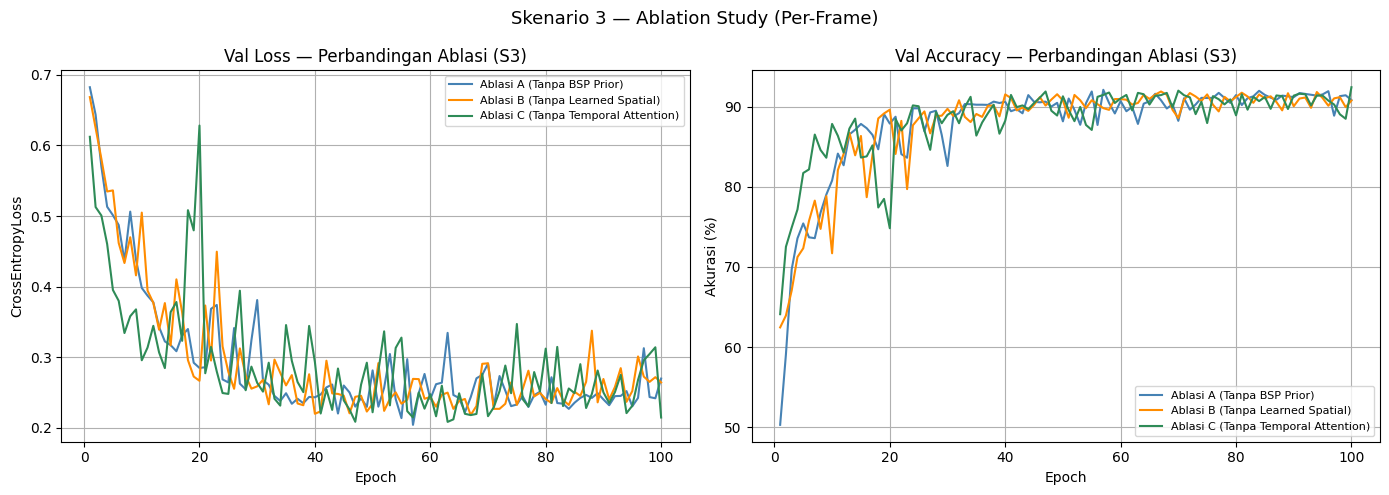

In [5]:
# ============================================================
# Visualisasi Perbandingan Kurva Val Loss Ketiga Ablasi
# ============================================================
# Warna untuk setiap ablasi agar mudah dibedakan
WARNA = {
    "Ablasi A (Tanpa BSP Prior)"            : "steelblue",
    "Ablasi B (Tanpa Learned Spatial)"      : "darkorange",
    "Ablasi C (Tanpa Temporal Attention)"   : "seagreen",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nama, history in all_histories.items():
    epochs = range(1, len(history["val_loss"]) + 1)
    warna  = WARNA.get(nama, "gray")

    # Plot Val Loss semua ablasi dalam satu grafik
    axes[0].plot(epochs, history["val_loss"], label=nama, color=warna)

    # Plot Val Accuracy semua ablasi
    axes[1].plot(epochs, [a * 100 for a in history["val_acc"]], label=nama, color=warna)

axes[0].set_title("Val Loss — Perbandingan Ablasi (S3)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropyLoss")
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].set_title("Val Accuracy — Perbandingan Ablasi (S3)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Akurasi (%)")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.suptitle("Skenario 3 — Ablation Study (Per-Frame)", fontsize=13)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "curve_s3_ablation_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# ============================================================
# Ringkasan Hasil — Tabel Perbandingan Semua Ablasi
# ============================================================
print(f"{'='*65}")
print(f"{'Skenario':<35} {'Best Epoch':>10} {'Val Loss':>10} {'Val Acc':>10}")
print(f"{'-'*65}")

for nama, history in all_histories.items():
    best_ep  = history['best_epoch']
    best_loss = history['best_val_loss']
    best_acc  = history['val_acc'][best_ep - 1] * 100
    print(f"{nama:<35} {best_ep:>10} {best_loss:>10.4f} {best_acc:>9.2f}%")

print(f"{'='*65}")
print("Catatan: Akurasi per prediksi frame (bukan per video).")

Skenario                            Best Epoch   Val Loss    Val Acc
-----------------------------------------------------------------
Ablasi A (Tanpa BSP Prior)                  57     0.2040     92.10%
Ablasi B (Tanpa Learned Spatial)            67     0.2179     91.89%
Ablasi C (Tanpa Temporal Attention)         63     0.2082     91.72%
Catatan: Akurasi per prediksi frame (bukan per video).
